<a href="https://colab.research.google.com/github/Vanitha-1111-ART/AI_INTERNSHIP/blob/main/WATER_POTABILITY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install snowflake-connector-python pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 1.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found ex

In [ ]:
import snowflake.connector
import pandas as pd
c = snowflake.connector.connect(
     user = 'Vanitha',
     password = 'Vanitha113106#',
     account = 'XIYRYAO-XP29254',
     database = 'WATER_POTABILITY',
     schema = 'PUBLIC',
     warehouse = 'COMPUTE_WH')
q= 'select * from "WATER"'
d = pd.read_sql(q,c)
print(d.head())
print(d.info())
print(d.shape)
print(d.describe())
print(d.isnull().sum())
print(d.tail())


/tmp/ipykernel_1810/1841046826.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  d = pd.read_sql(q,c)


         PH    HARDNESS        SOLIDS  CHLORAMINES     SULFATE  CONDUCTIVITY  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  -

In [ ]:
#preprocessing
d1 =d.copy()
d2 = d.copy()
d3 =d.copy()

<Axes: >

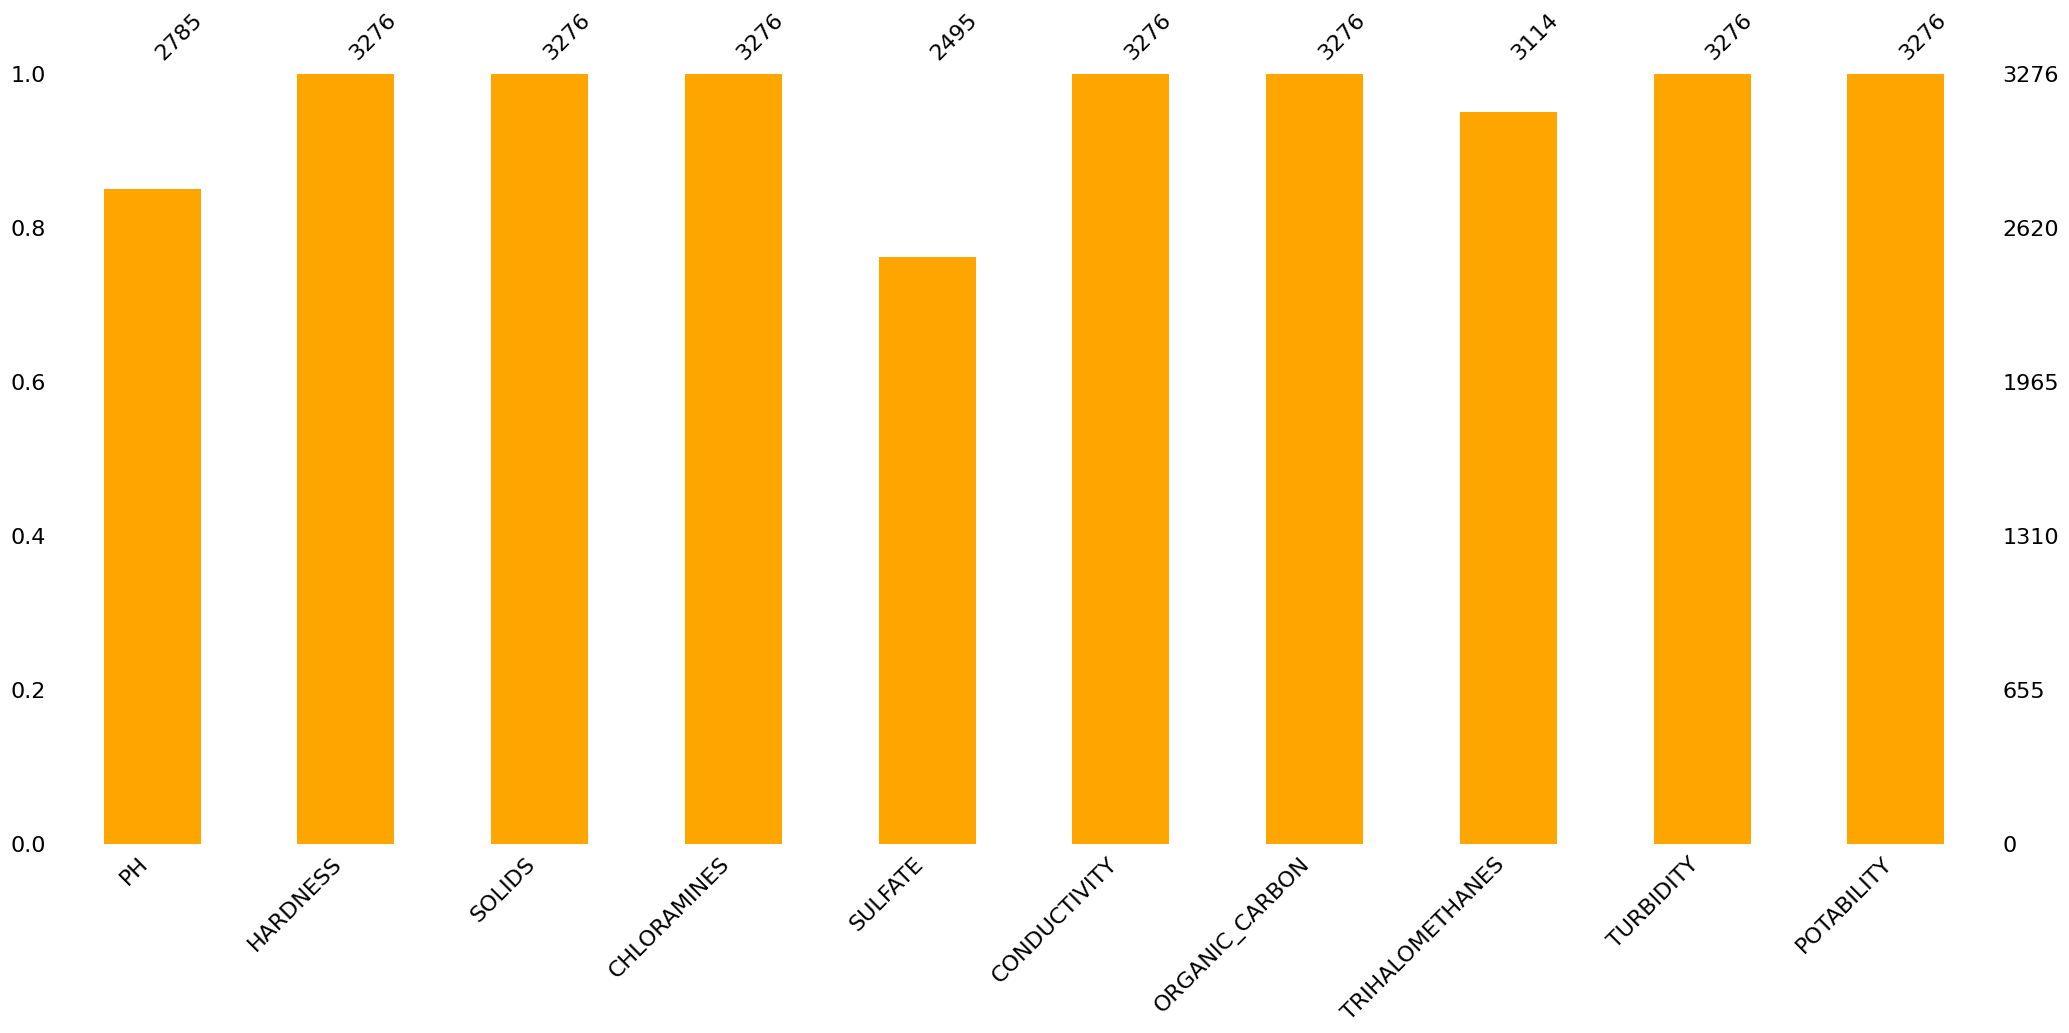

In [ ]:
#missingno
!pip install missingno
import missingno as ms
ms.bar(d,color = "orange")

<Axes: >

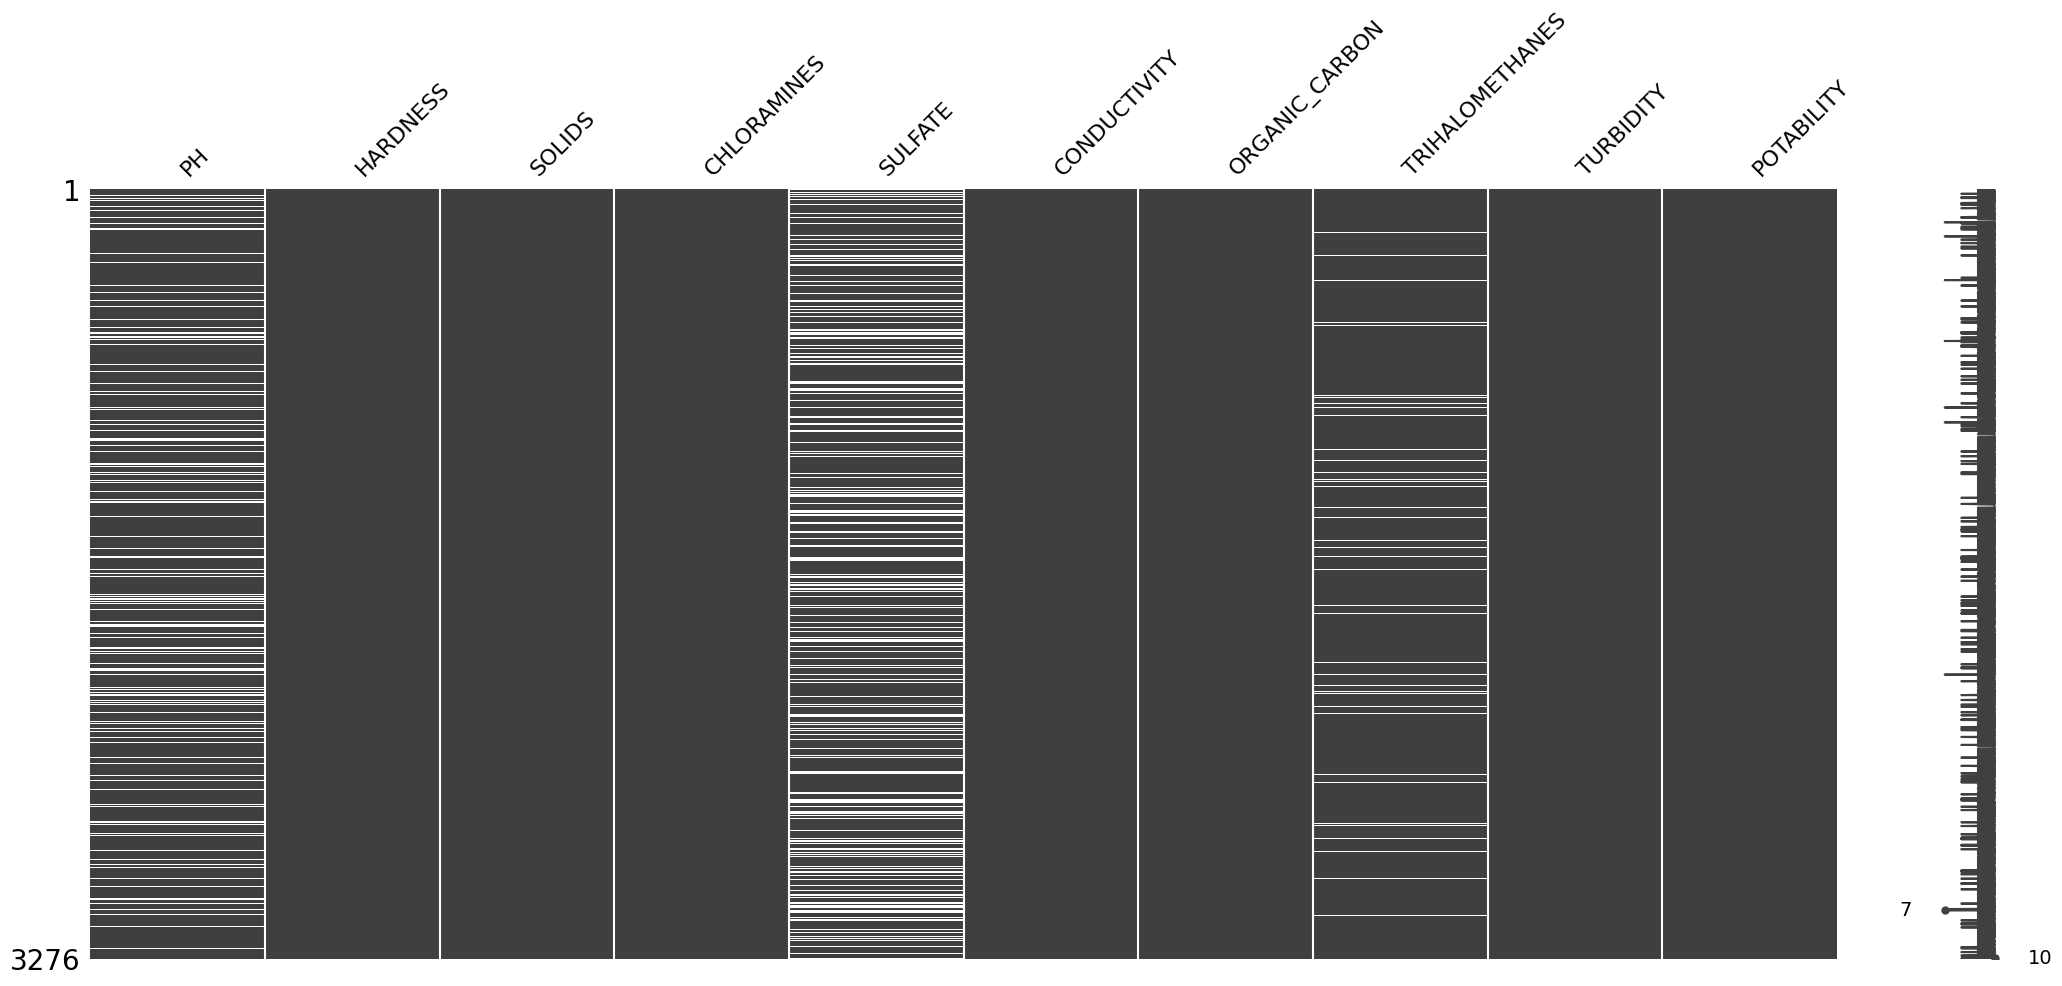

In [ ]:
ms.matrix(d)

<Axes: >

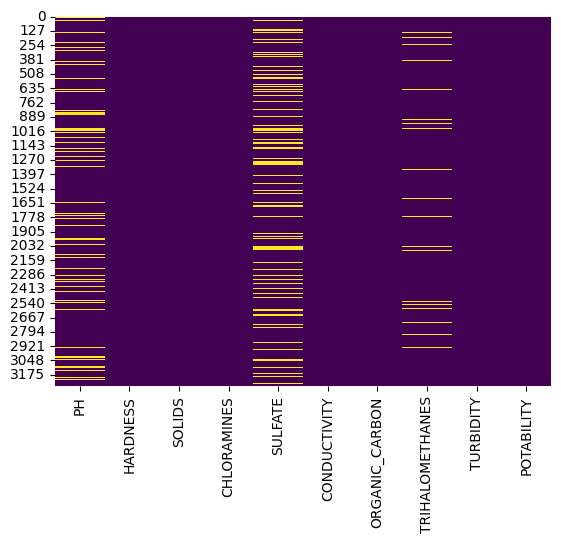

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(d.isnull(),cbar=False,cmap='viridis')

In [ ]:
#fillna
d1['PH'] = d1['PH'].fillna(d1['PH'].mean())
d1['SULFATE'] = d1['SULFATE'].fillna(d1['SULFATE'].mean())
d1['TRIHALOMETHANES'] = d1['TRIHALOMETHANES'].fillna(d1['TRIHALOMETHANES'].mean())



In [ ]:
d1.isnull().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0
POTABILITY,0


In [ ]:
from  sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy ='mean')
d2[['PH']] = imp.fit_transform(d2[['PH']])
d2[['TRIHALOMETHANES']] = imp.fit_transform(d2[['TRIHALOMETHANES']])
d2[['SULFATE']] = imp.fit_transform(d2[['SULFATE']])

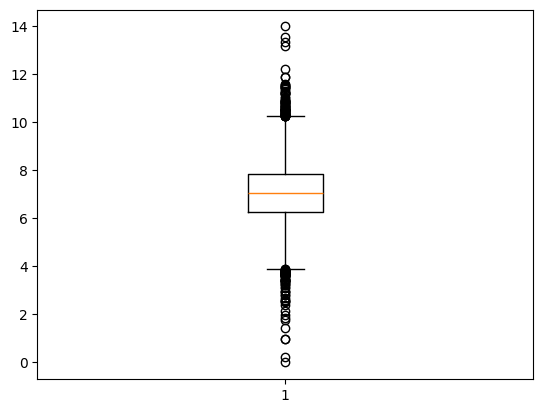

In [ ]:
plt.boxplot(d1['PH'])
plt.show()

In [ ]:
Q1=d1['PH'].quantile(0.25)
Q3=d1['PH'].quantile(0.75)
IQR=Q3-Q1

In [ ]:
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

In [ ]:
outlier=d1[(d1['PH']<lower) | (d1['PH']>upper)]

In [ ]:
outlier

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0
26,3.445062,207.926260,33424.768678,8.782147,384.007006,441.785876,13.805902,30.284597,4.184397,0
32,10.433291,117.791230,22326.892046,8.161505,307.707509,412.986834,12.890709,65.733478,5.057311,0
36,3.641630,183.908722,24752.072460,5.538314,286.059556,456.860096,9.034067,73.594657,3.464353,0
...,...,...,...,...,...,...,...,...,...,...
3233,10.485604,136.577381,32872.380566,8.399435,276.921835,416.188546,18.884625,60.078413,4.669240,1
3246,10.667364,173.381945,28912.202201,7.071294,276.634391,286.063394,17.685651,55.147364,4.135569,1
3249,10.808157,198.596751,29614.348790,5.782418,304.622061,383.269410,14.902820,47.896406,4.362542,1
3261,3.629922,244.187392,24856.633209,6.618071,366.967873,442.076337,13.302880,59.489294,4.754826,1


In [ ]:
from scipy.stats import zscore
z=zscore(d1['PH'])
print(z)

[-6.04313345e-16 -2.28933938e+00  6.92867789e-01 ...  1.59125368e+00
 -1.32951593e+00  5.40150905e-01]


In [ ]:
d1[np.abs(z)>2.9]

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
80,1.844538,233.764343,28689.595778,7.724432,333.775777,410.387264,15.611859,54.299444,5.013463,0
104,2.612036,188.804126,34798.252587,6.796439,333.775777,468.080267,13.170763,49.523770,4.765205,0
263,13.175402,47.432000,19237.949676,8.907020,375.147315,500.245952,12.083896,66.396293,4.106924,1
354,2.798549,311.383956,26931.243483,7.116897,333.775777,521.140524,14.235154,42.080353,3.663252,1
692,1.757037,147.581831,41538.242730,7.728177,376.012933,428.444823,10.828696,65.005840,2.967554,1
726,0.227499,152.530111,39028.599340,3.462492,283.693782,443.029232,13.201943,62.322711,3.545741,1
783,11.898078,228.132673,8296.550611,9.899637,346.649750,500.169210,15.486862,63.529460,3.024968,1
810,0.989912,133.216942,16922.853899,9.293289,444.375731,322.291191,10.430076,43.578466,5.160604,1
1231,2.690831,151.782906,30204.546735,6.053072,303.702409,377.198273,14.121049,45.602992,4.650034,0
1303,12.246928,217.368014,11318.140563,8.465160,375.894758,347.653054,9.762505,73.832405,3.533243,0


In [ ]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=0.4)
d1['outlier']=iso.fit_predict(d1[['PH','TRIHALOMETHANES']])

In [ ]:
d1

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY,outlier
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,1
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0,-1
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0,1
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,-1
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1,-1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1,-1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1,-1


In [ ]:
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from scipy.stats import boxcox

In [ ]:
d1['PH']=winsorize(d1['PH'],limits=[0.05,0.05])

In [ ]:
d1['PH']=np.log1p(d1['PH'])

In [ ]:
s=StandardScaler()
d1[['PH']]=s.fit_transform(d1[['PH']])

In [ ]:
m=MinMaxScaler()
d1[['PH']]=m.fit_transform(d1[['PH']])

In [ ]:
m=MinMaxScaler()
d1[['PH']]=m.fit_transform(d1[['PH']])

In [ ]:
p=PowerTransformer(method='yeo-johnson')
d1[['PH']]=p.fit_transform(d1[['PH']])

In [ ]:
data,lambda_value=boxcox(d1['PH'])
d1['ans']=data

ValueError: Data must be positive.

In [ ]:
d1

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY,outlier
0,0.023945,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,1
1,-1.948774,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0,-1
2,0.806582,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0,1
3,0.969105,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,-1
4,1.534794,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
3271,-1.948774,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1,-1
3272,0.587228,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1,1
3273,1.767400,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1,-1
3274,-1.572749,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1,-1


In [ ]:
#Encoding
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
d1['PH']=l.fit_transform(d1['PH'])
d1

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY,outlier
0,1260,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,1
1,0,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0,-1
2,1945,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0,1
3,2071,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,-1
4,2347,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
3271,0,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1,-1
3272,1762,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1,1
3273,2419,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1,-1
3274,120,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1,-1


In [ ]:
from sklearn.preprocessing import OneHotEncoder
o=OneHotEncoder(sparse_output=False)
d1['PH']=o.fit_transform(d1[['PH']])
d1

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY,outlier
0,0.0,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,1
1,1.0,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0,-1
2,0.0,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0,1
3,0.0,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,-1
4,0.0,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
3271,1.0,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1,-1
3272,0.0,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1,1
3273,0.0,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1,-1
3274,0.0,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1,-1


In [ ]:
d1=pd.get_dummies(d1,columns=['PH'])
d1

,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY,outlier,PH_0.0,PH_1.0
0,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,1,True,False
1,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0,-1,False,True
2,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0,1,True,False
3,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,-1,True,False
4,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,-1,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
3271,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1,-1,False,True
3272,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1,1,True,False
3273,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1,-1,True,False
3274,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1,-1,True,False
